# Low northern variance $\sigma_{16}$


In [1]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.mlab as mlab
import numpy as np
import healpy as hp
import polymv
import pylab as pl
import math
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Parameters
load_stats_from_cluster = True
gen_maps_on_fly         = False
ecliptic_coords         = True
Nside_out               = 16
save_stats              = True
remove_mon_dip          = False

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

In [3]:
# Directories
sims_dir  = "../../data/sims/"
stats_dir = "../../data/stats/"
real_dir  = "../../data/real/"
masks_dir = "../../data/masks/"

# Planck maps
names_Planck  = ["cleaned_70GHz_v9_nside_128",     "cleaned_94GHz_v9_nside_128", "cleaned_100GHz_v9_nside_128", "cleaned_143GHz_v9_nside_128",   "commander_nside_128",   "nilc_nside_128",   "sevem_nside_128",   "smica_nside_128"]
labels_Planck = [      r"$70\, \mathrm{GHz}$",           r"$94\, \mathrm{GHz}$",       r"$100\, \mathrm{GHz}$",       r"$143\, \mathrm{GHz}$", r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$"]
colors_Planck = ["tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [      "-",    "-",     "-",     "-",      "--",      "--",     "--",    "--"]
Nmaps = len(names_Planck)
index_Planck  = 4
index_Hayley  = 2


# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
mask_files = ["stdv_mask_1percent_cutoff_0.9_nside_16.fits", "com_mask_cutoff_0.9_nside_16.fits"]
mask_fn_south_ecl = "mask_south_ecl_nside_16.fits"
Nmasks = len(names_mask)

# Cls
cl_fn = "../../data/Cls/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}
prop = {'family': 'Helvetica', 'size': 20}

# Read maps & masks

In [5]:
# Read masks and save 0's as NaN's
masks_01   = CMBanom.read_masks(masks_dir, mask_files, Nside_out)
masks_bool = np.array([np.logical_not(masks_01[m]) for m in range(Nmasks)])

if ecliptic_coords:
    mask_for_north = hp.read_map(masks_dir+mask_fn_south_ecl)
    mask_for_south = np.where(hp.read_map(masks_dir+mask_fn_south_ecl)==1, 0, 1)
else:
    mask_for_north = np.append(np.ones(len_mask_16/2), np.zeros(len_mask_16/2))
    mask_for_north = np.append(np.zeros(len_mask_16/2), np.ones(len_mask_16/2))

masks = np.where(np.array([mask*mask_for_north for mask in masks_01])==0, np.NaN, 1)
#masks = np.where(np.array([mask*mask_for_south for mask in masks_01])==0, np.NaN, 1)
masks_south = np.where(np.array([mask*mask_for_south for mask in masks_01])==0, np.NaN, 1)

In [6]:
# Read in maps in muK
maps_Planck_hr = [hp.read_map(real_dir+"map_"+names_Planck[n]+".fits") for n in range(Nmaps)]
maps_Planck = np.array([CMBanom.downgrade_map(maps_Planck_hr[n], Nside_out) for n in range(Nmaps)])

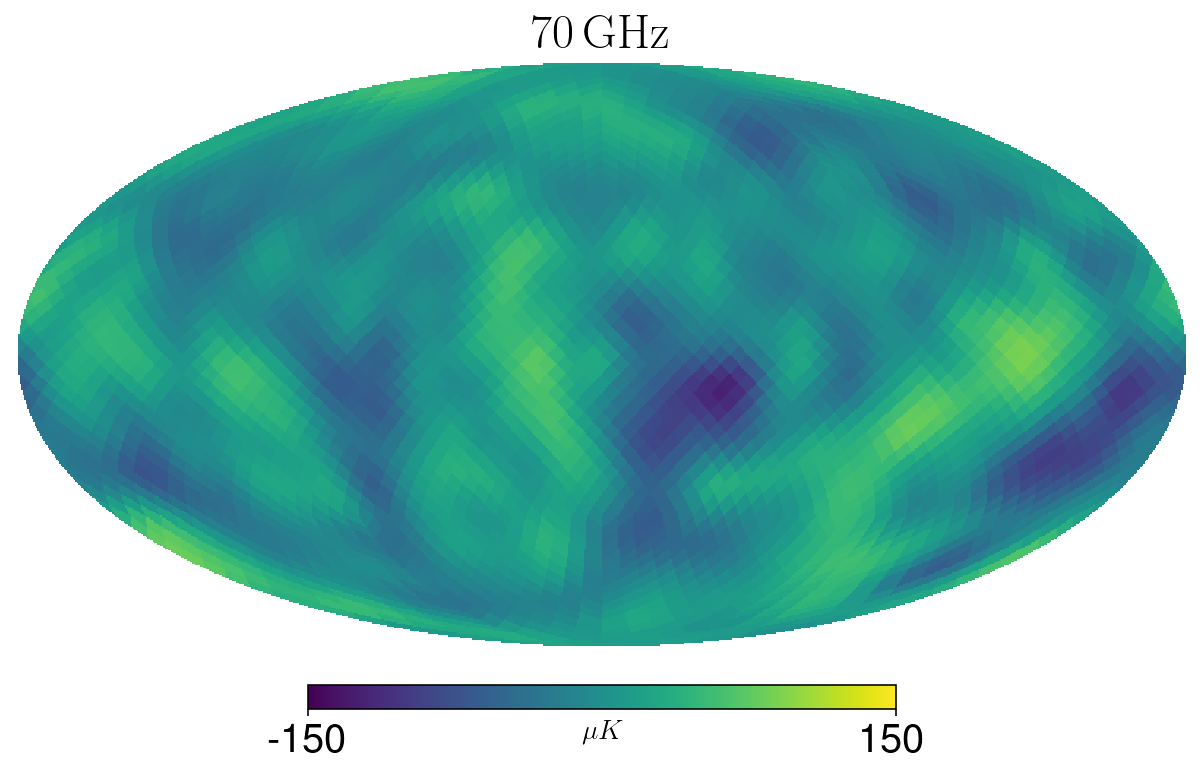

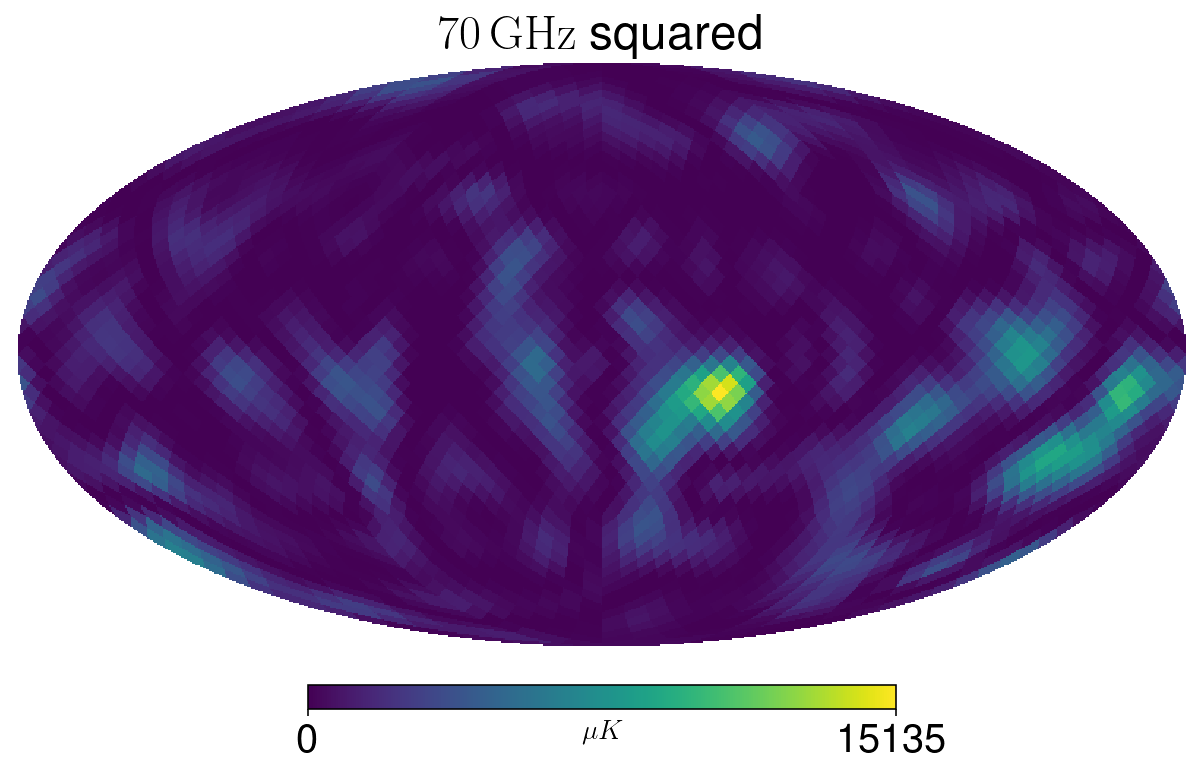

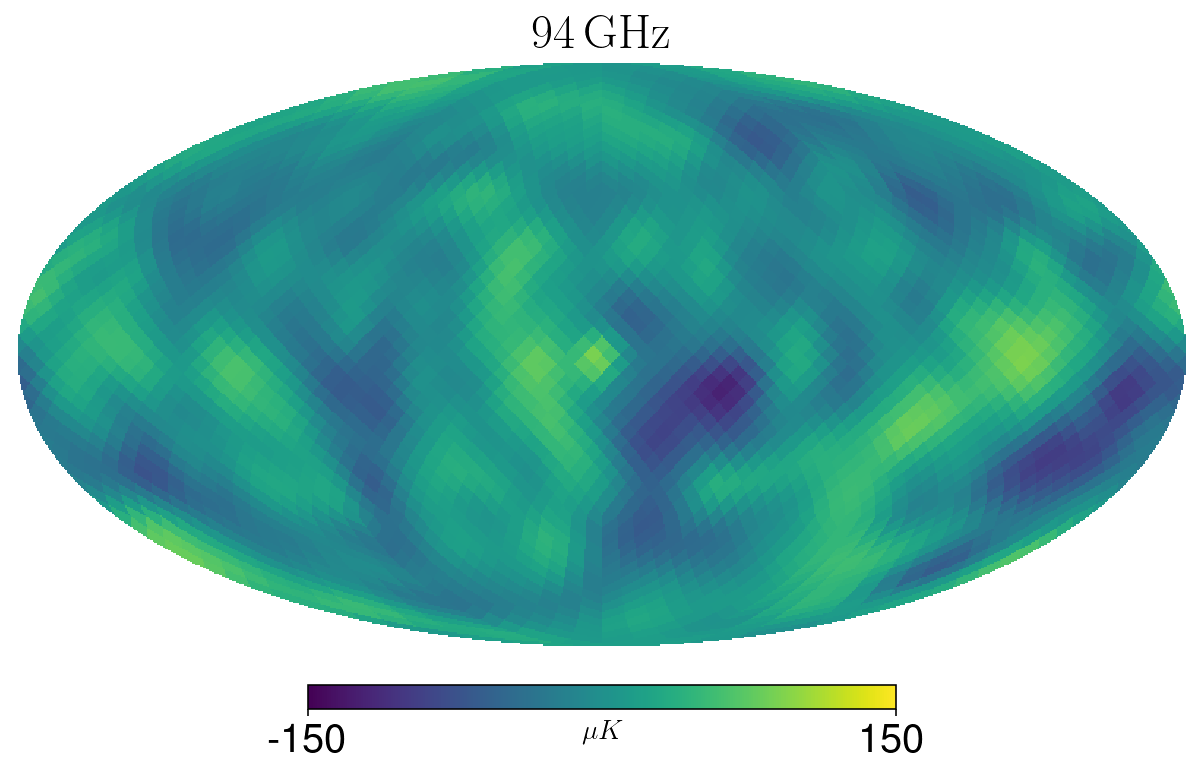

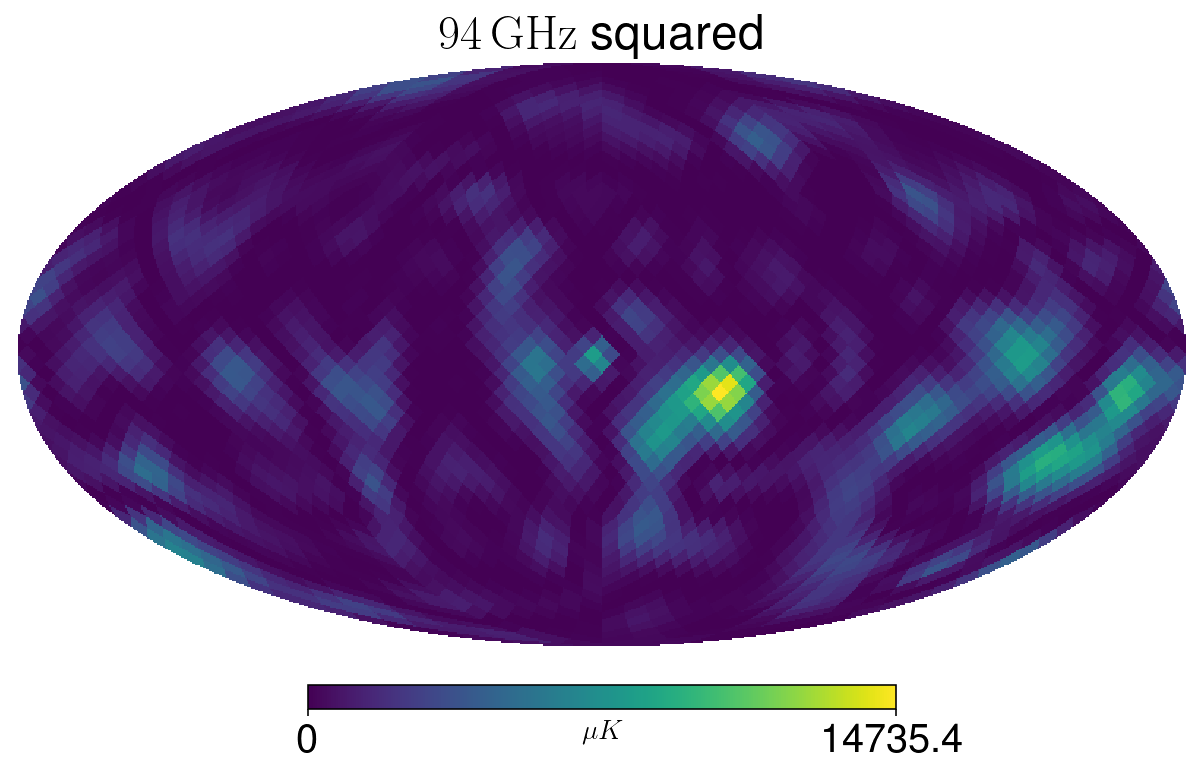

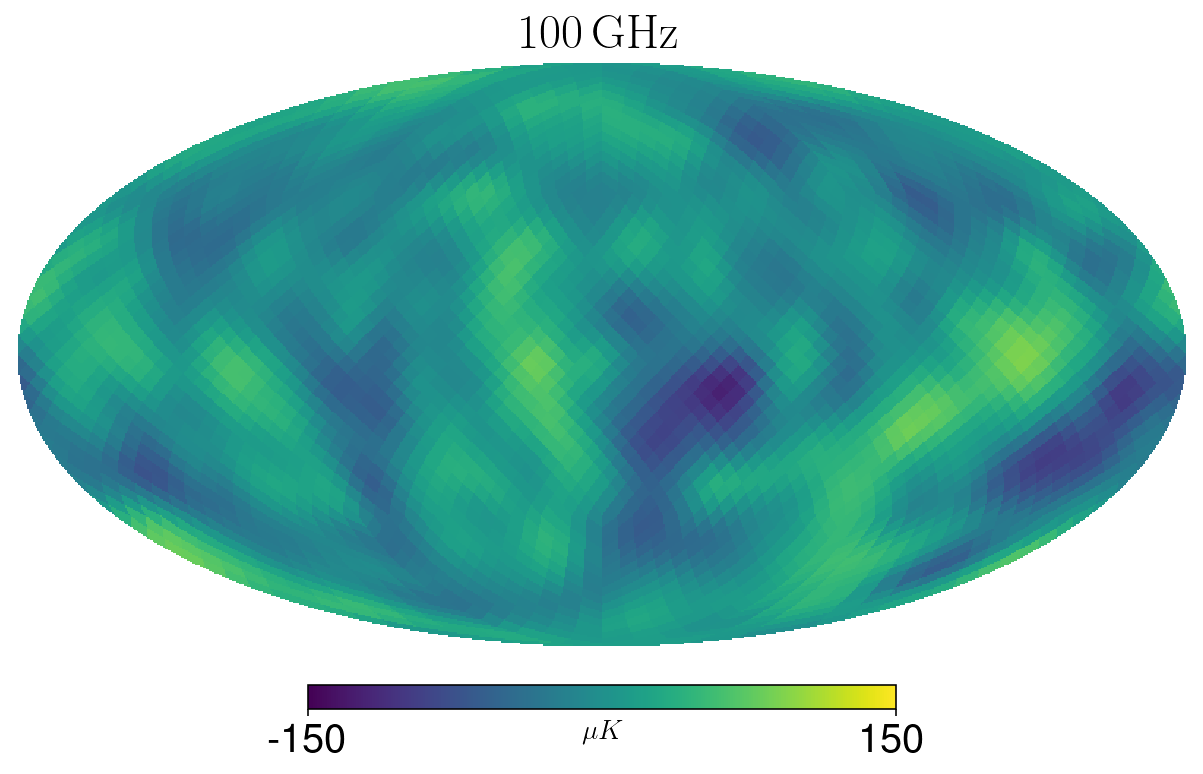

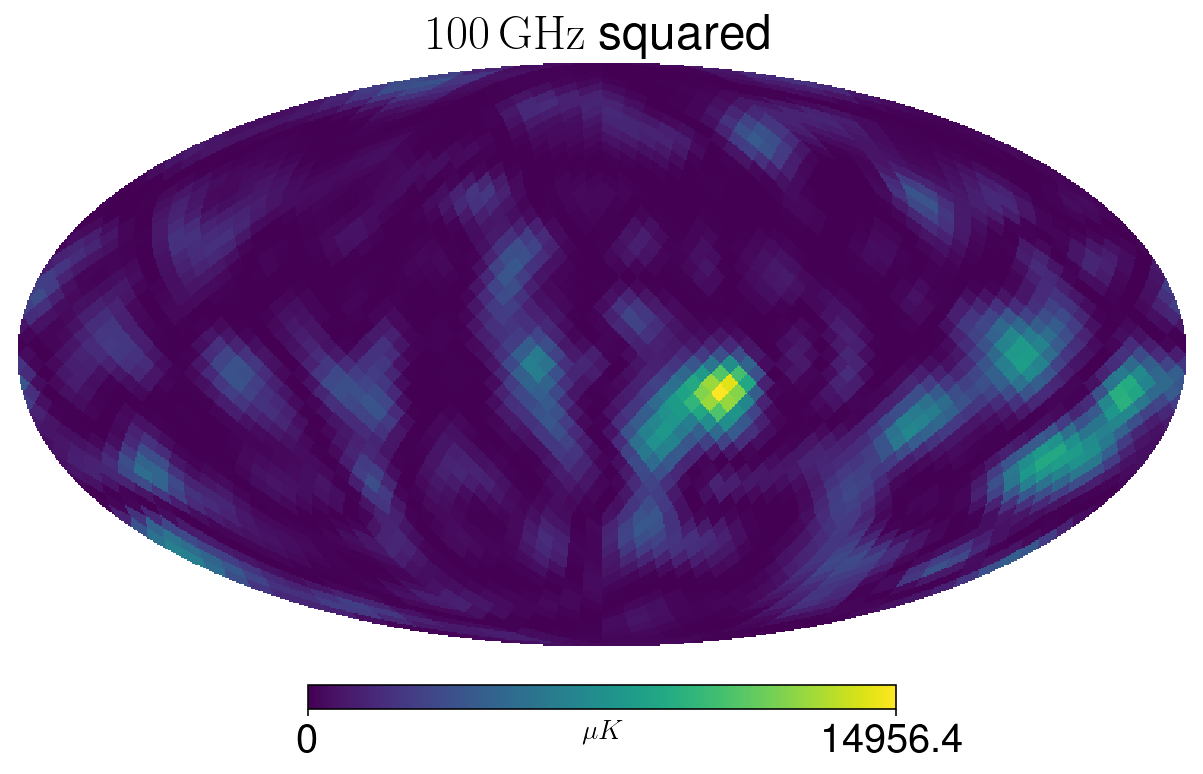

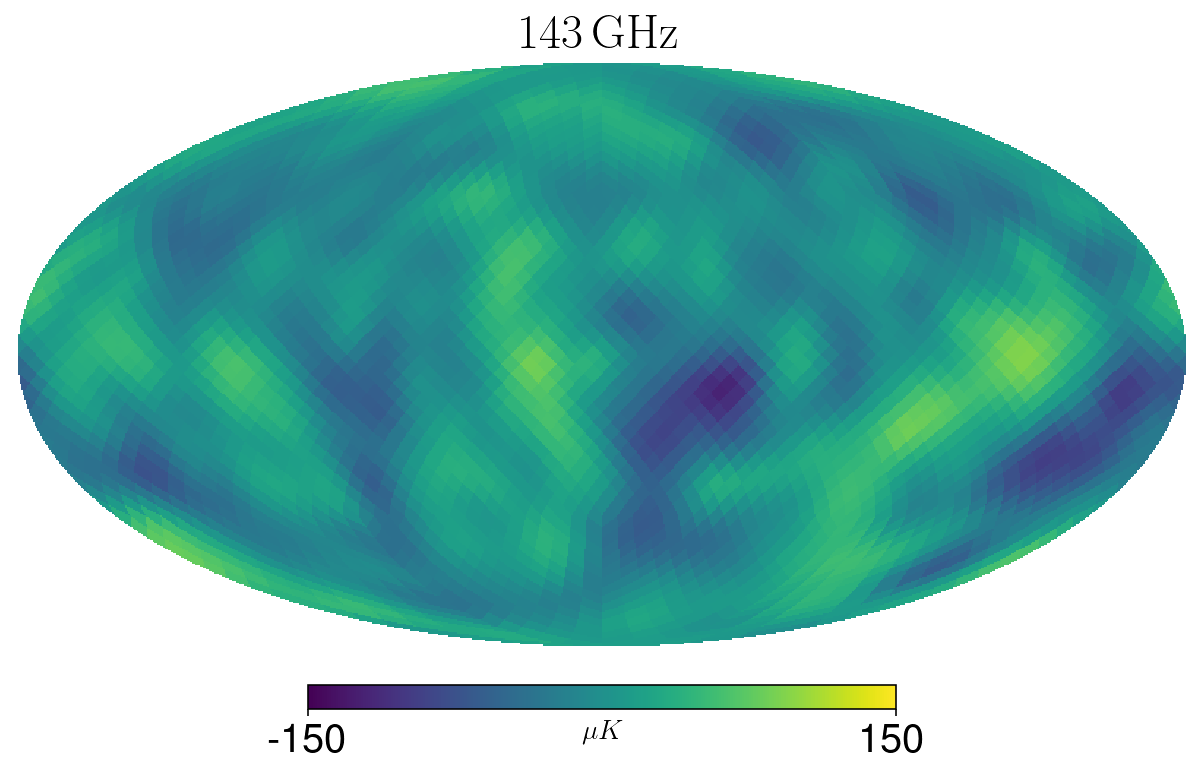

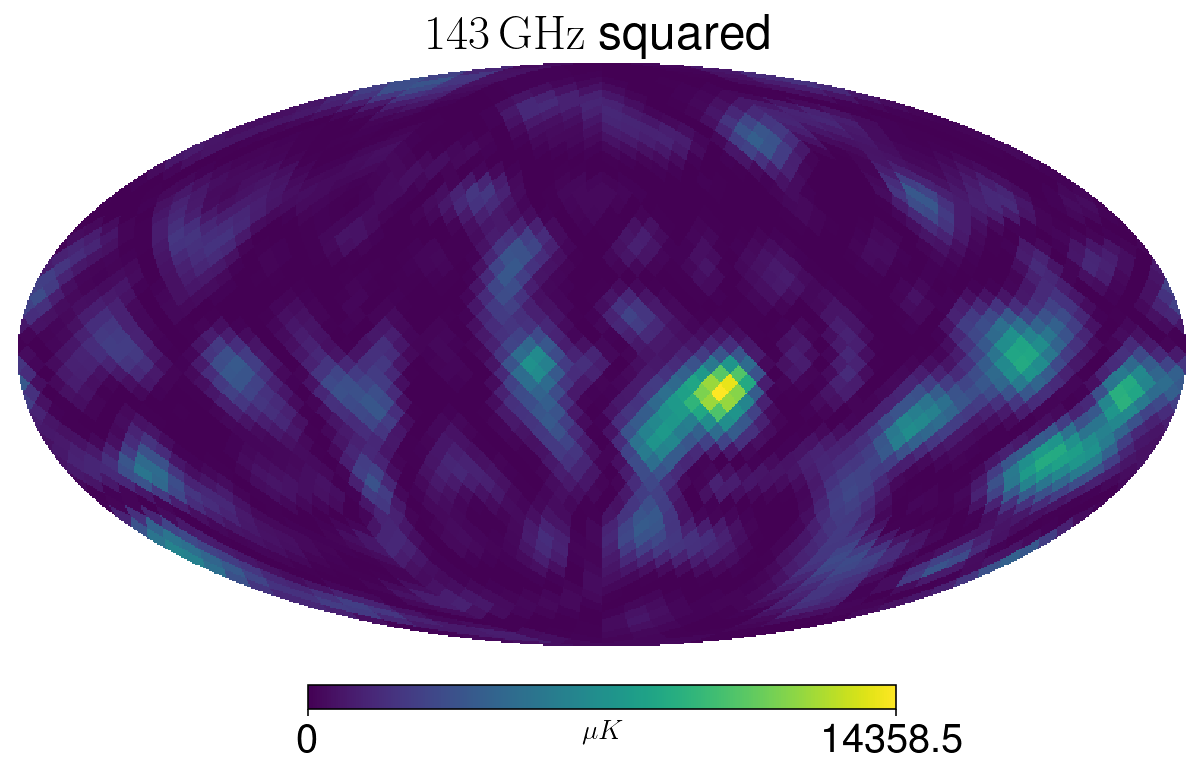

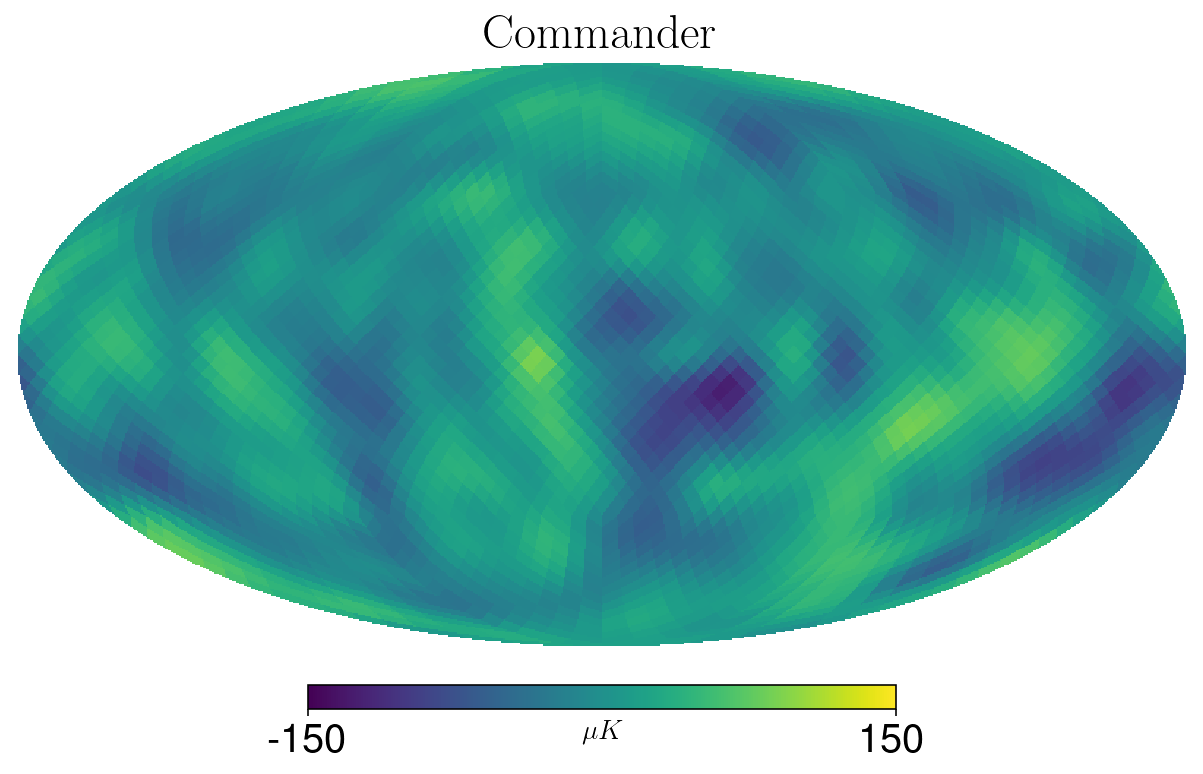

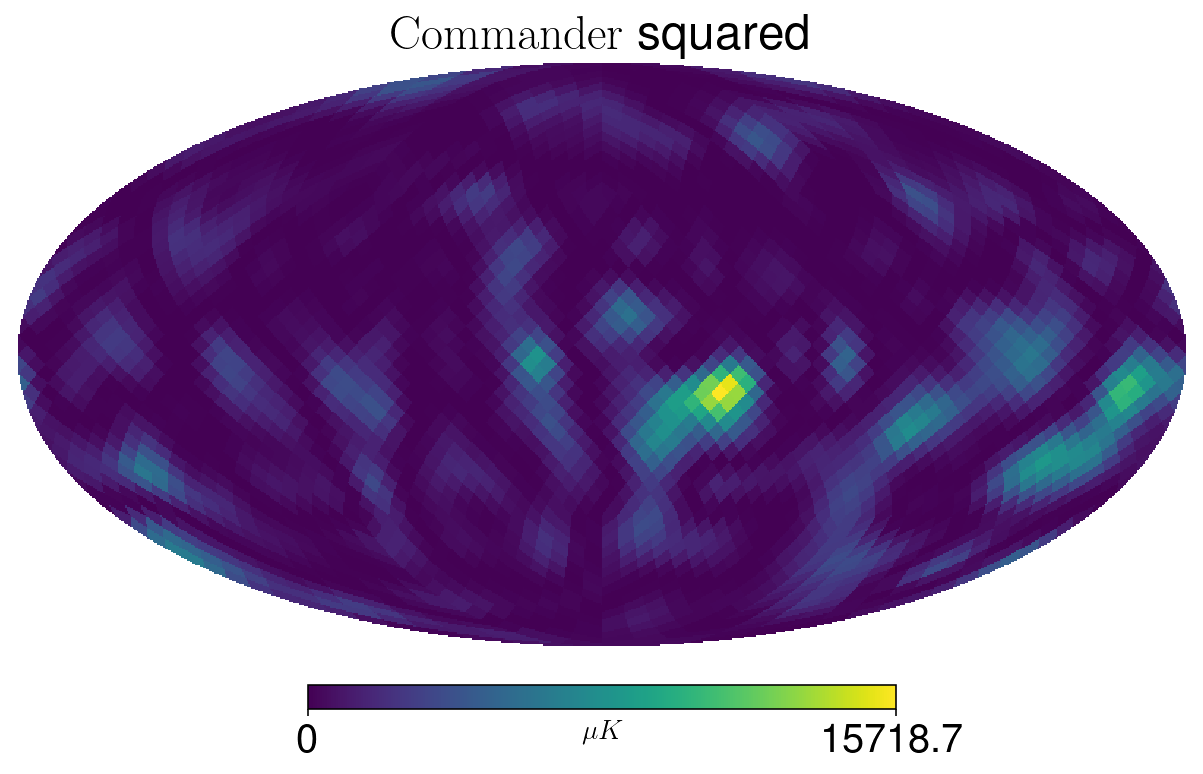

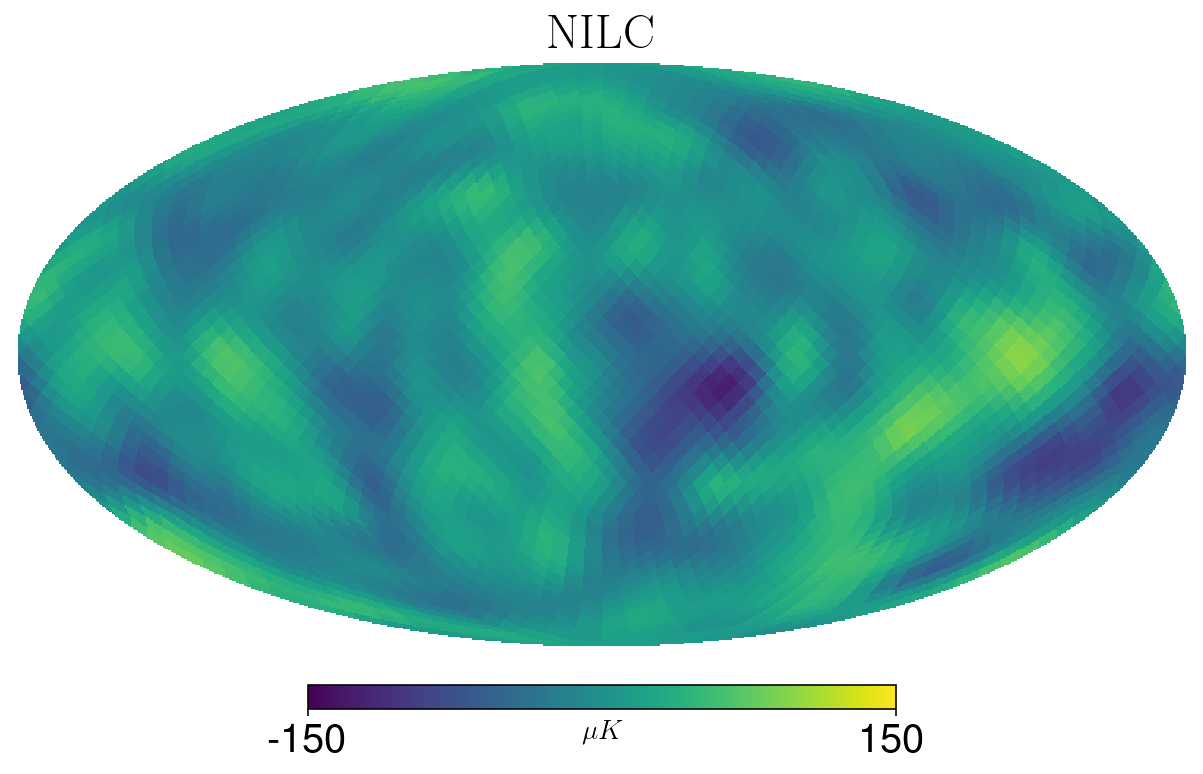

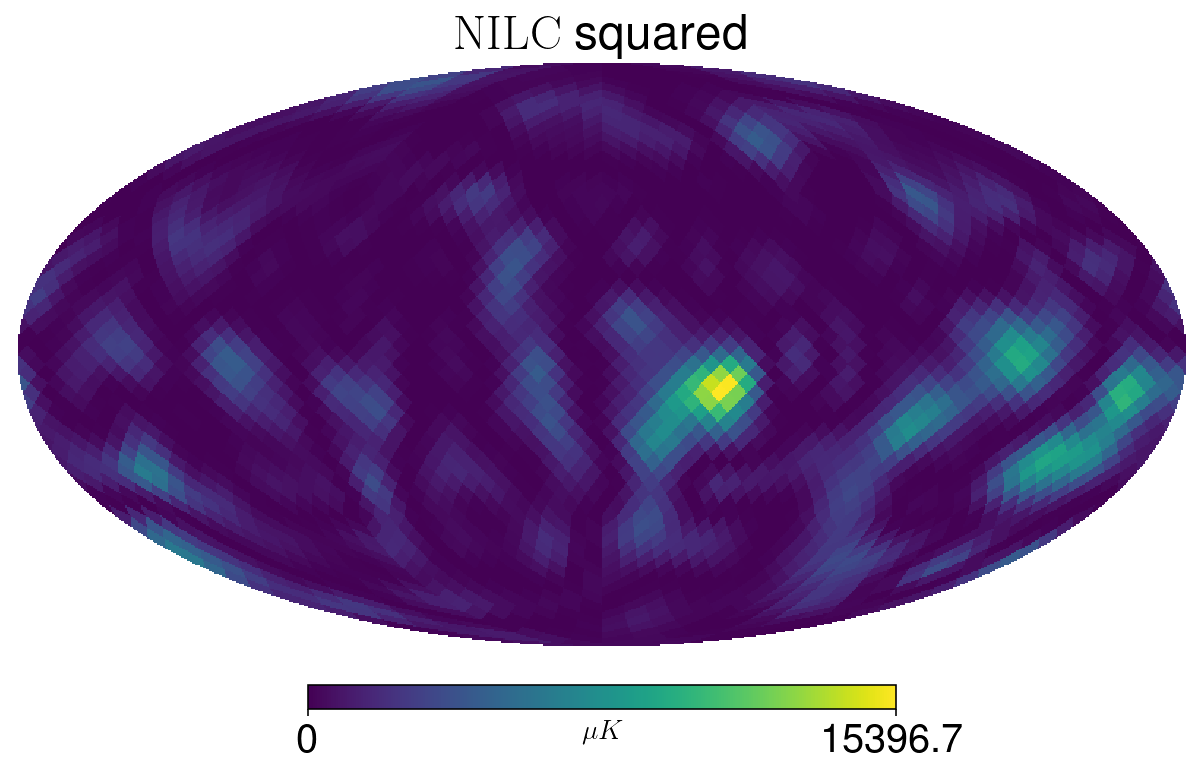

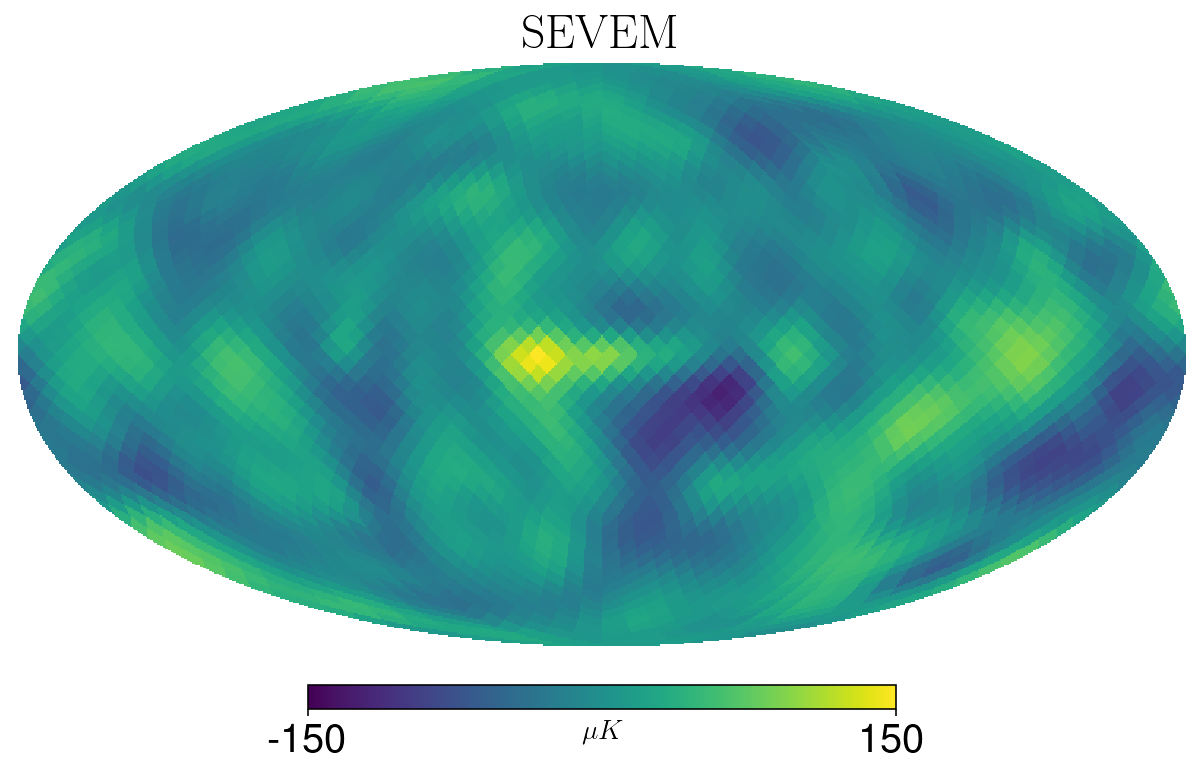

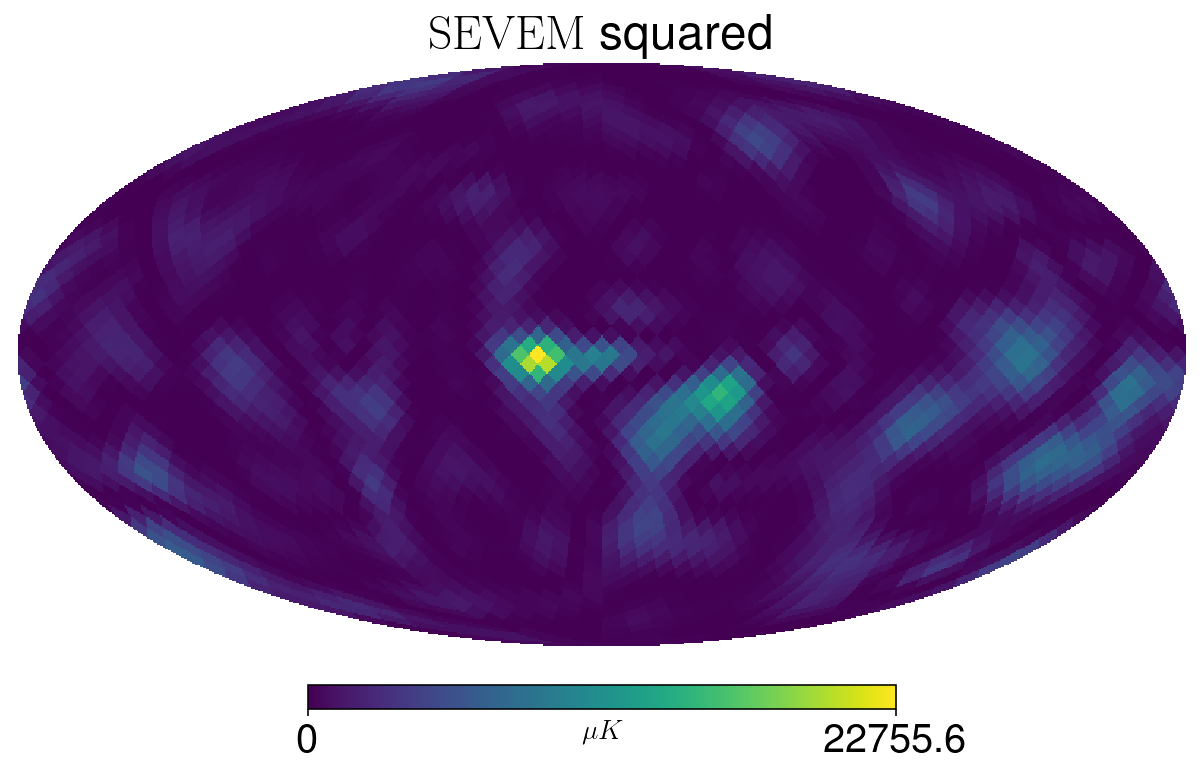

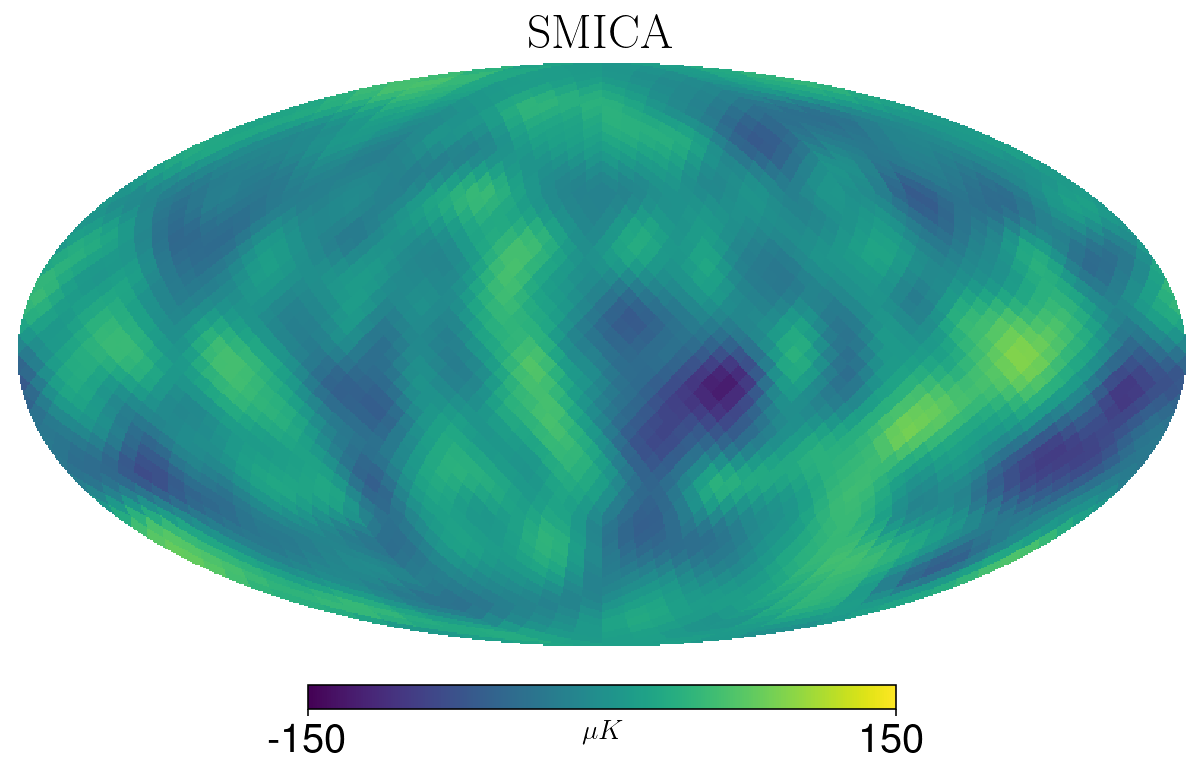

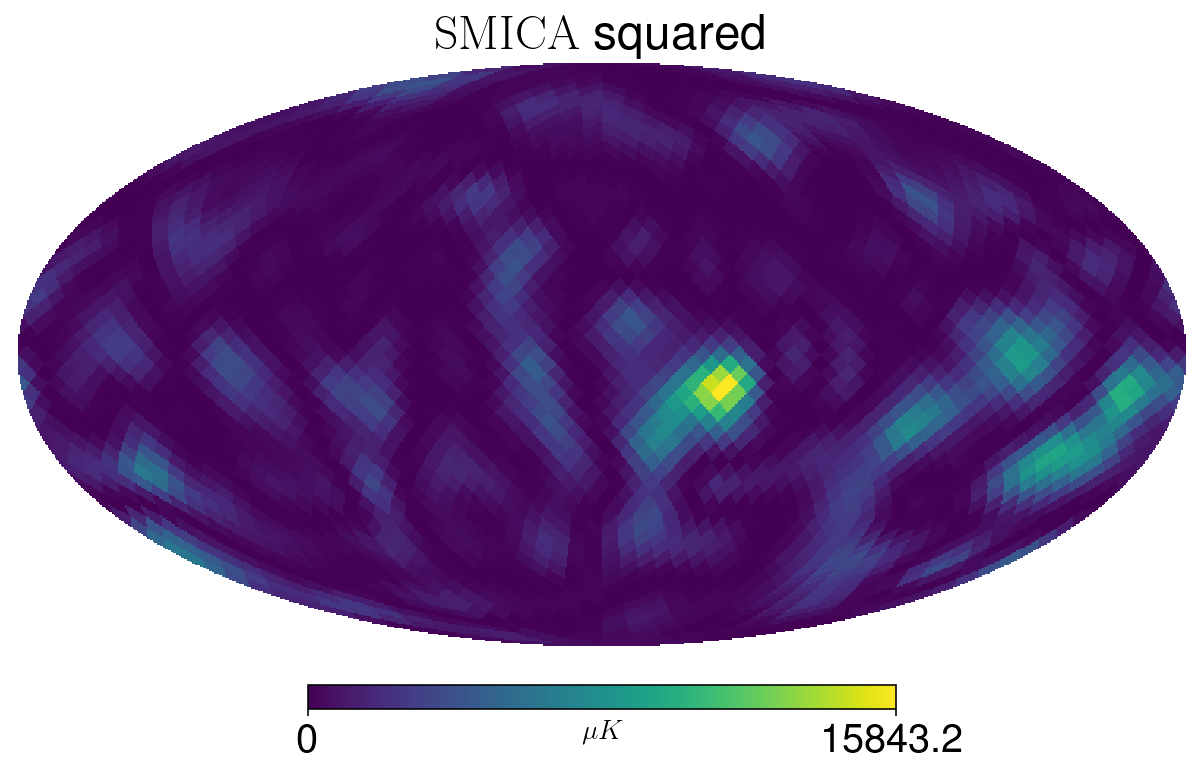

In [7]:
# Plot maps
m=0
for n in range(Nmaps): 
    hp.mollview(maps_Planck[n], min=-150, max=150, unit=r"$\mu K$", title=labels_Planck[n])
    hp.mollview(maps_Planck[n]**2, min=0, unit=r"$\mu K$", title=labels_Planck[n]+" squared")

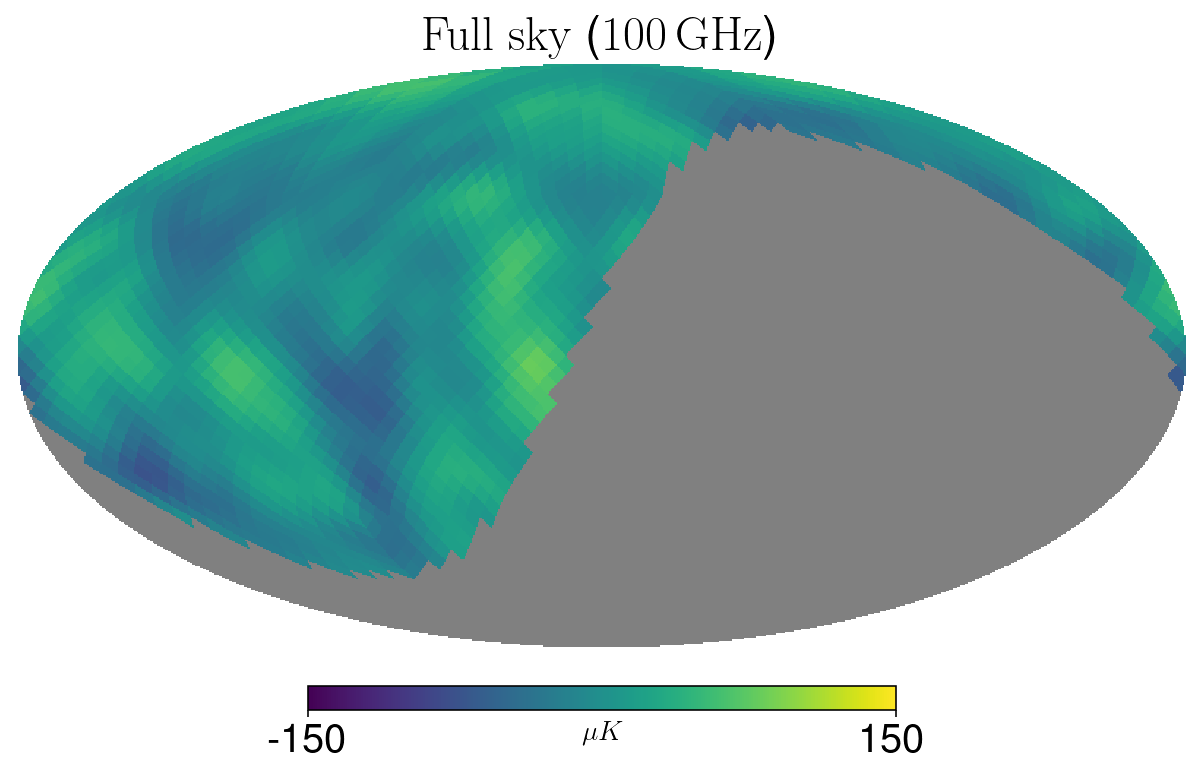

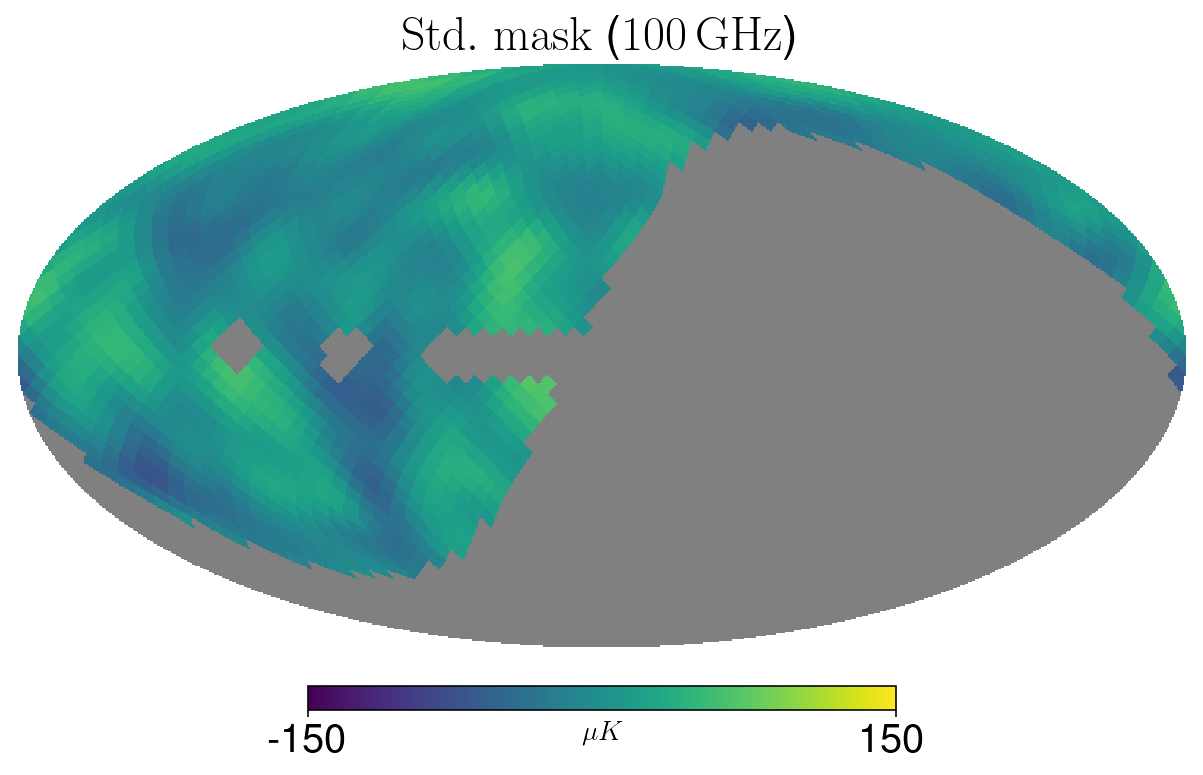

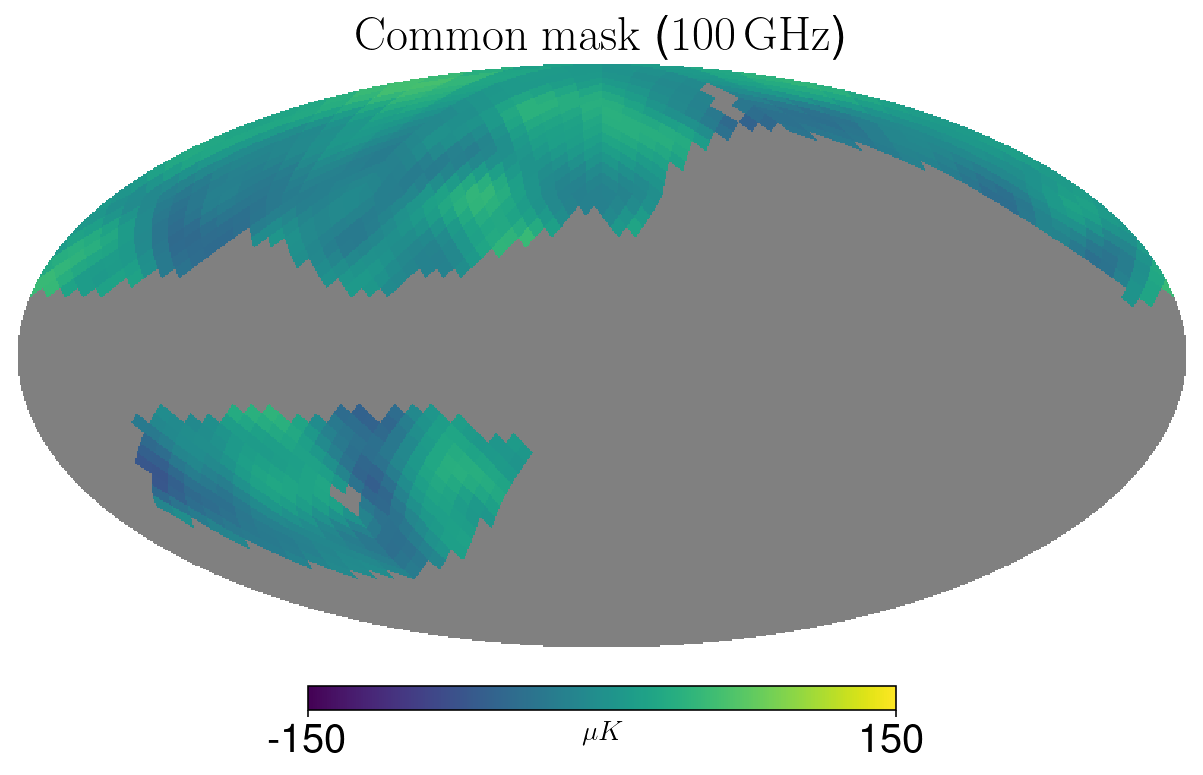

In [8]:
# Plot masks
n = 2
for m in range(Nmasks): hp.mollview(maps_Planck[n]*masks[m], min=-150, max=150, unit=r"$\mu K$", title=f"{labels_mask[m]} ({labels_Planck[n]})")

In [9]:
# Print sky fractions
print("Sky fractions:")
for m in range(Nmasks):
    print(f"{names_mask[m]}: {100*len(masks[m][~np.isnan(masks[m])])/len(masks[m]):.1f} %")

Sky fractions:
fullsky: 49.2 %
stdmask: 47.3 %
commask: 31.8 %


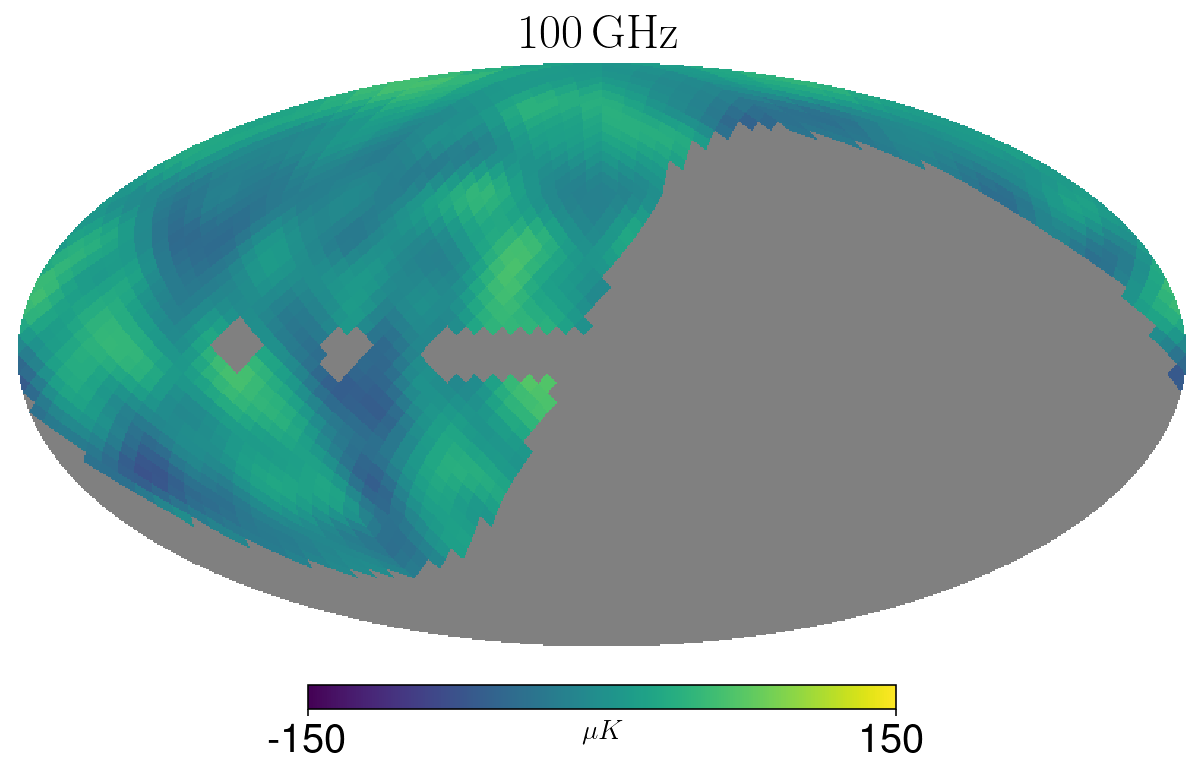

In [10]:
# Save 100 GHz for paper
hp.mollview(maps_Planck[index_Hayley]*masks[1], min=-150, max=150, unit=r"$\mu K$", title=labels_Planck[index_Hayley])
#plt.tight_layout()
plt.savefig("map_nside16_100GHz.pdf", format="PDF", bbox_inches='tight')

# Variance real maps

In [11]:
if remove_mon_dip: 
    vars_Planck = np.array([[CMBanom.sigma2_16(CMBanom.remove_dipole(maps_Planck[n], masks_bool[m]), masks[m]) for n in range(Nmaps)] for m in range(Nmasks)])
else:
    vars_Planck = np.array([[CMBanom.sigma2_16(maps_Planck[n], masks[m]) for n in range(Nmaps)] for m in range(Nmasks)])
    

# Variance sims
Generate maps, compute variance on northern hemisphere on the fly without saving the map

In [12]:
if load_stats_from_cluster:
    vars_sims = [np.loadtxt(stats_dir+f"sigma16_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
else:
    if gen_maps_on_fly:
        NSIDEtoFWHMarcmin = {2048:5, 1024:10, 512:20, 256:40, 128:80, 64:160, 32:320, 16:640}
        lmax=200
        data = np.loadtxt(cl_fn, skiprows=1)
        llist = np.arange(lmax+1)
        Clist = np.zeros(lmax+1)
        Clist[2:] = data[:lmax-1, 1]*2.*np.pi/(llist[2:]*(llist[2:] + 1))

        # Generate maps and save var
        vars_sims = [[],[],[]]
        seeds = np.arange(0,Nsims)
        for seed in seeds:
            np.random.seed(seed)
            m_128 = hp.sphtfunc.synfast(Clist, nside=128, fwhm=CMBanom.arcmin2rad(NSIDEtoFWHMarcmin[128]), pixwin=True)  
            m = CMBanom.downgrade_map(m_128, Nside_out)
            vars_sims[0].append(CMBanom.sigma_16(m, mask_for_north))
            vars_sims[1].append(CMBanom.sigma_16(m, mask_for_north*mask_std))
            vars_sims[2].append(CMBanom.sigma_16(m, mask_for_north*mask_com))
        
    else:
        maps_128  = [hp.read_map(sims_dir+f"map__{n}.fits") for n in range(Nsims)]
        maps_16   = [CMBanom.downgrade_map(map, Nside_out) for map in maps_128]
        if remove_mon_dip: 
            vars_sims = [[CMBanom.sigma2_16(CMBanom.remove_dipole(map, masks_bool[m]), masks[m]) for map in maps_16] for m in range(Nmasks)]
        else: 
            vars_sims = [[CMBanom.sigma2_16(map, masks[m]) for map in maps_16] for m in range(Nmasks)]
    hp.mollview(maps_16[12]*masks[1], title="sim", unit=r"$\mu K$", min=-150, max=150)
mean_vars_sims = np.mean(np.array(vars_sims),axis=1)

# Compare northern & southern hemisphere

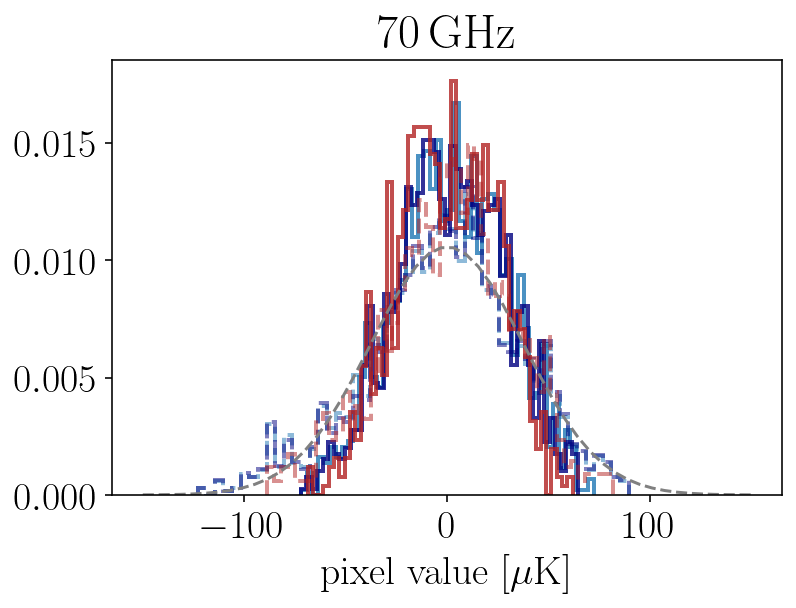

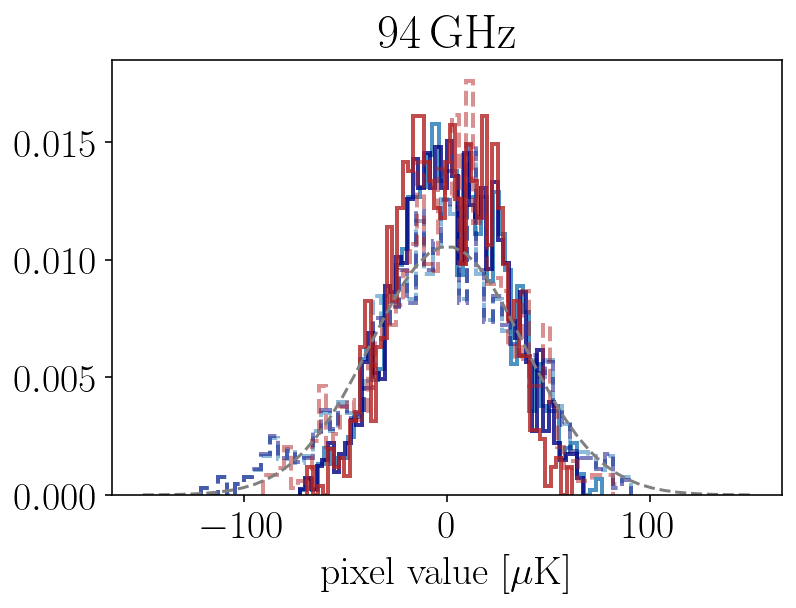

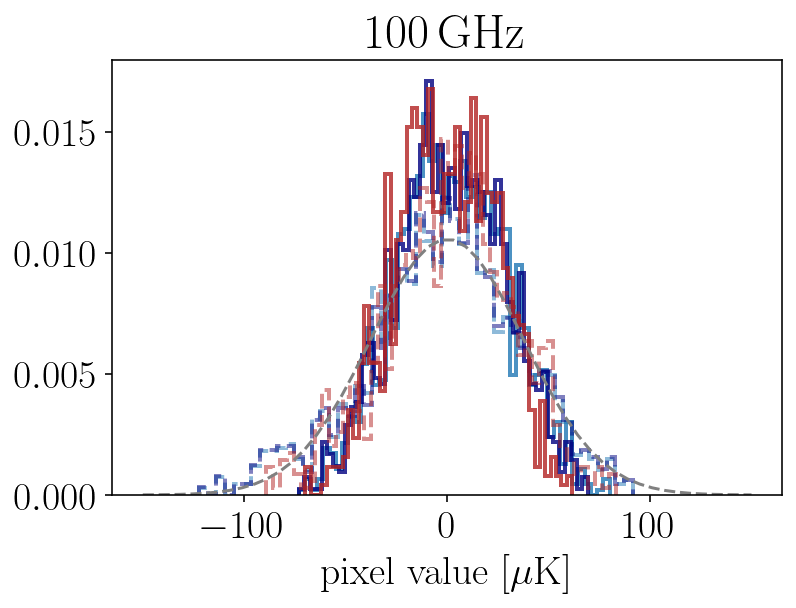

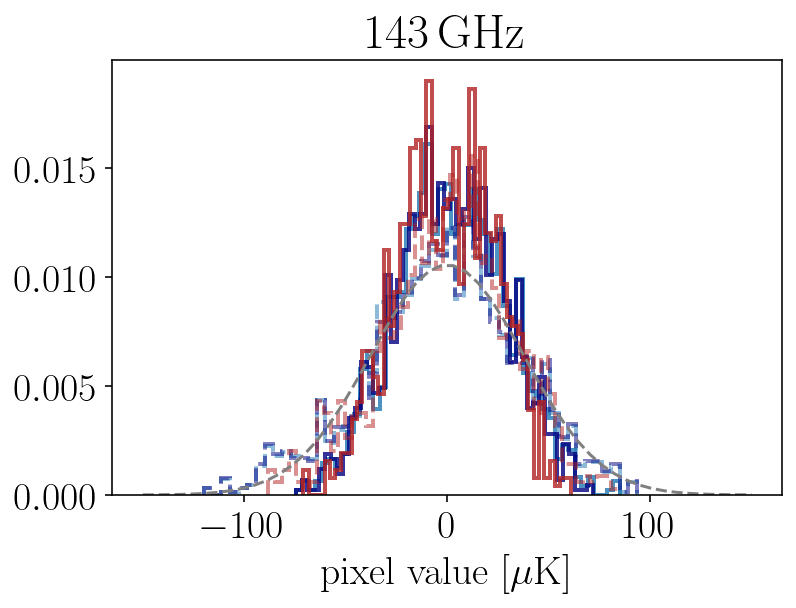

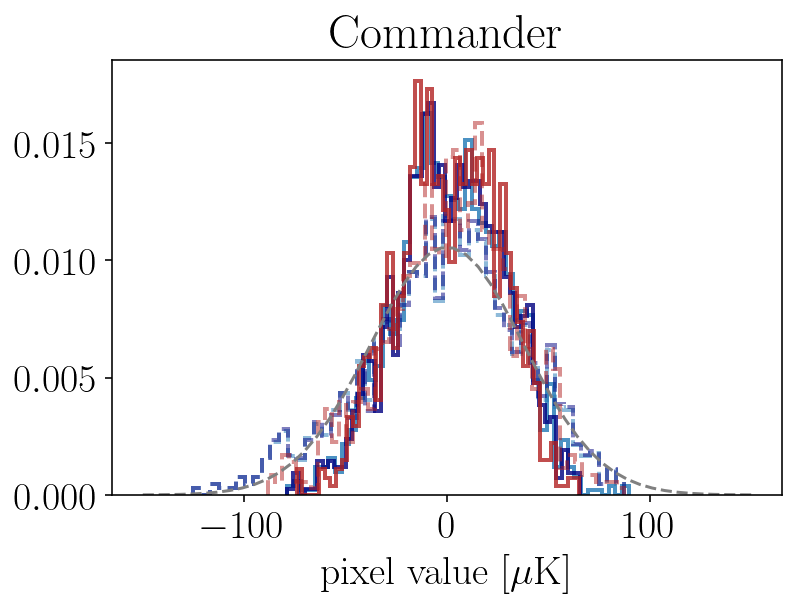

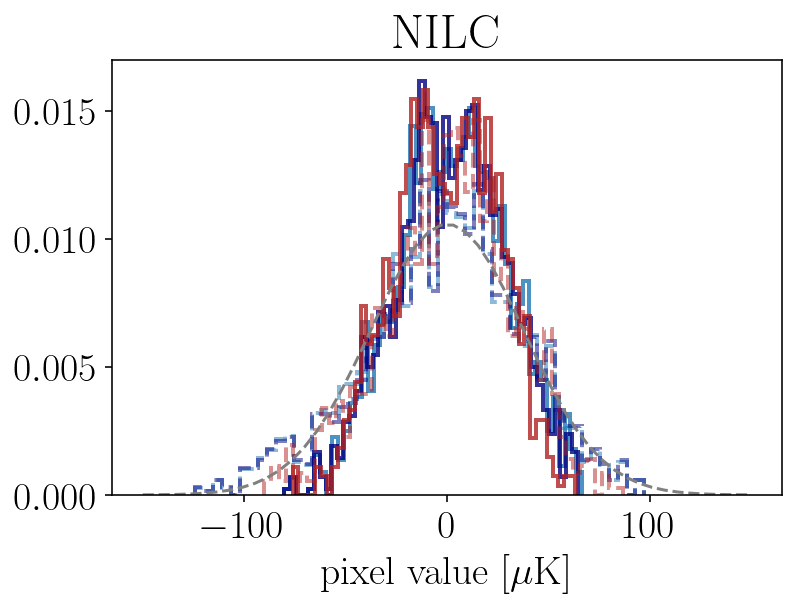

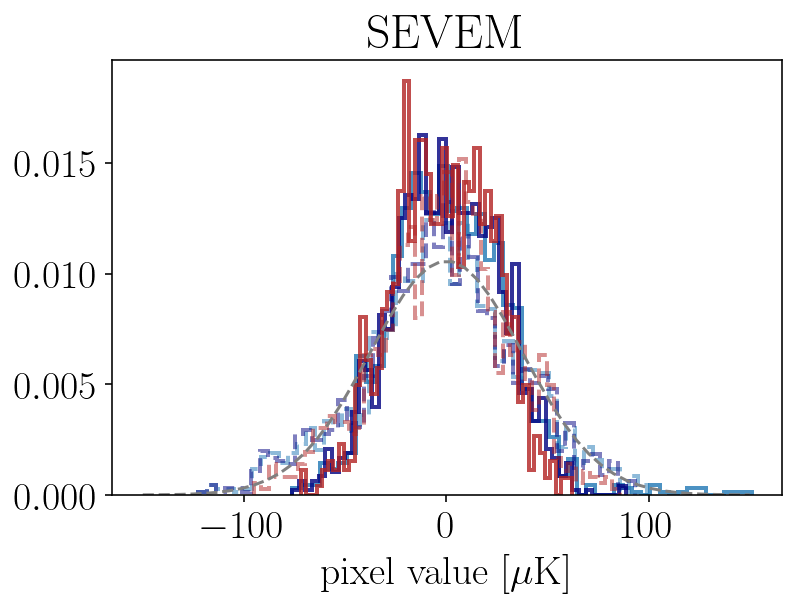

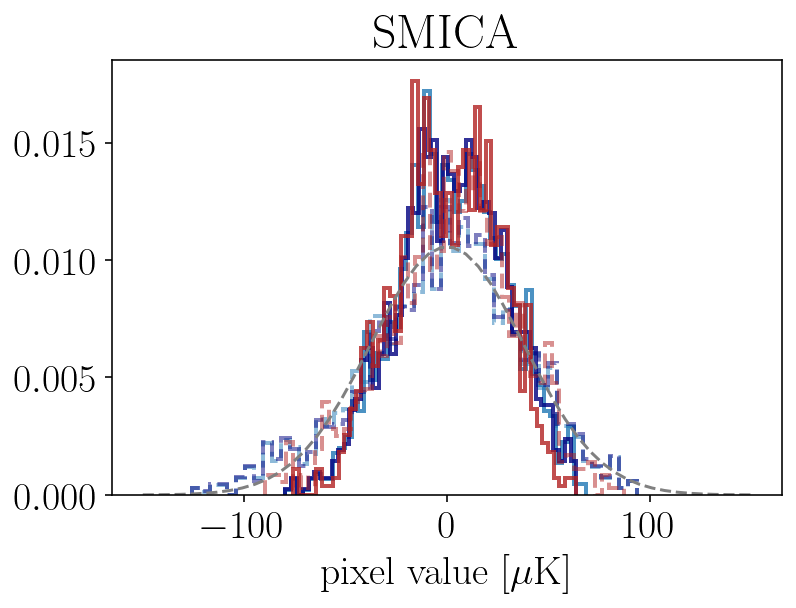

In [13]:
for n in range(Nmaps):
    plt.plot([0], [0], color='grey', alpha=0.8, ls="-",  lw=3, label=r'$\mathrm{Northern\ hemisphere}$')
    plt.plot([0], [0], color='grey', alpha=0.5, ls="--", lw=3, label=r'$\mathrm{Southern\ hemisphere}$')
    for m in range(Nmasks):
        h=plt.hist(maps_Planck[n]*masks[m], bins=50, alpha=0.8, label=labels_mask[m], histtype="step", lw=2, color=colors_mask[m], density=True)
        h=plt.hist(maps_Planck[n]*masks_south[m], bins=50, alpha=0.5, histtype="step", lw=2, color=colors_mask[m], density=True, ls="--")
    plt.plot(np.linspace(-150,150, 50), norm.pdf(np.linspace(-150,150, 50), 0, np.sqrt(mean_vars_sims[0])), color="grey", ls="--")

    plt.title(labels_Planck[n])
    plt.xlabel(r"$\mathrm{pixel\ value\ [}\mu \mathrm{K]}$")
    #plt.legend(loc="upper left", prop=prop)
    plt.show()

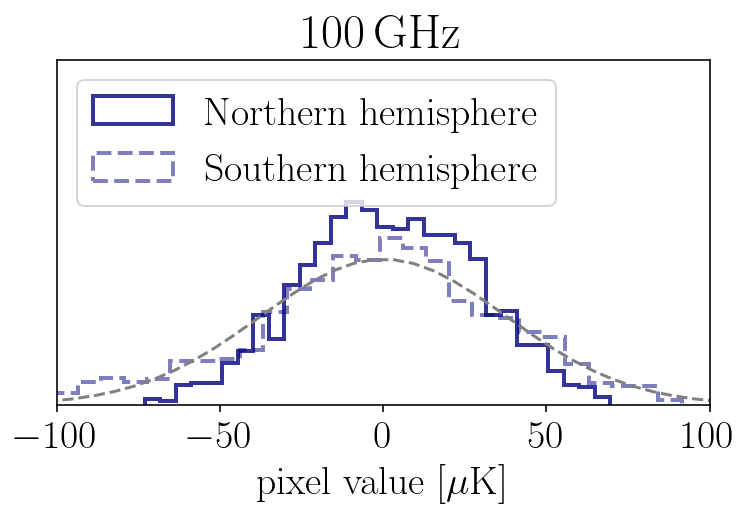

In [14]:
m=1
h=plt.hist(maps_Planck[index_Hayley]*masks[m], bins=30, alpha=0.8, histtype="step", lw=2, color=colors_mask[m], density=True, label=r'$\mathrm{Northern\ hemisphere}$')
h=plt.hist(maps_Planck[index_Hayley]*masks_south[m], bins=30, alpha=0.5, histtype="step", lw=2, color=colors_mask[m], density=True, ls="--", label=r'$\mathrm{Southern\ hemisphere}$')
plt.plot(np.linspace(-150,150, 50), norm.pdf(np.linspace(-150,150, 50), 0, np.sqrt(mean_vars_sims[0])), color="grey", ls="--")

plt.title(labels_Planck[index_Hayley])
plt.xlabel(r"$\mathrm{pixel\ value\ [}\mu \mathrm{K]}$")
plt.legend(loc="upper left", prop=prop)
plt.xlim(-100, 100)
plt.ylim(0, 0.025)
plt.tight_layout()
plt.yticks([])
plt.savefig("pixel_histogram_100GHz.pdf", format="PDF")
plt.show()

# Save stats to file

In [15]:
if save_stats: np.save(stats_dir+"sigma16_real", vars_Planck)

# Results plots

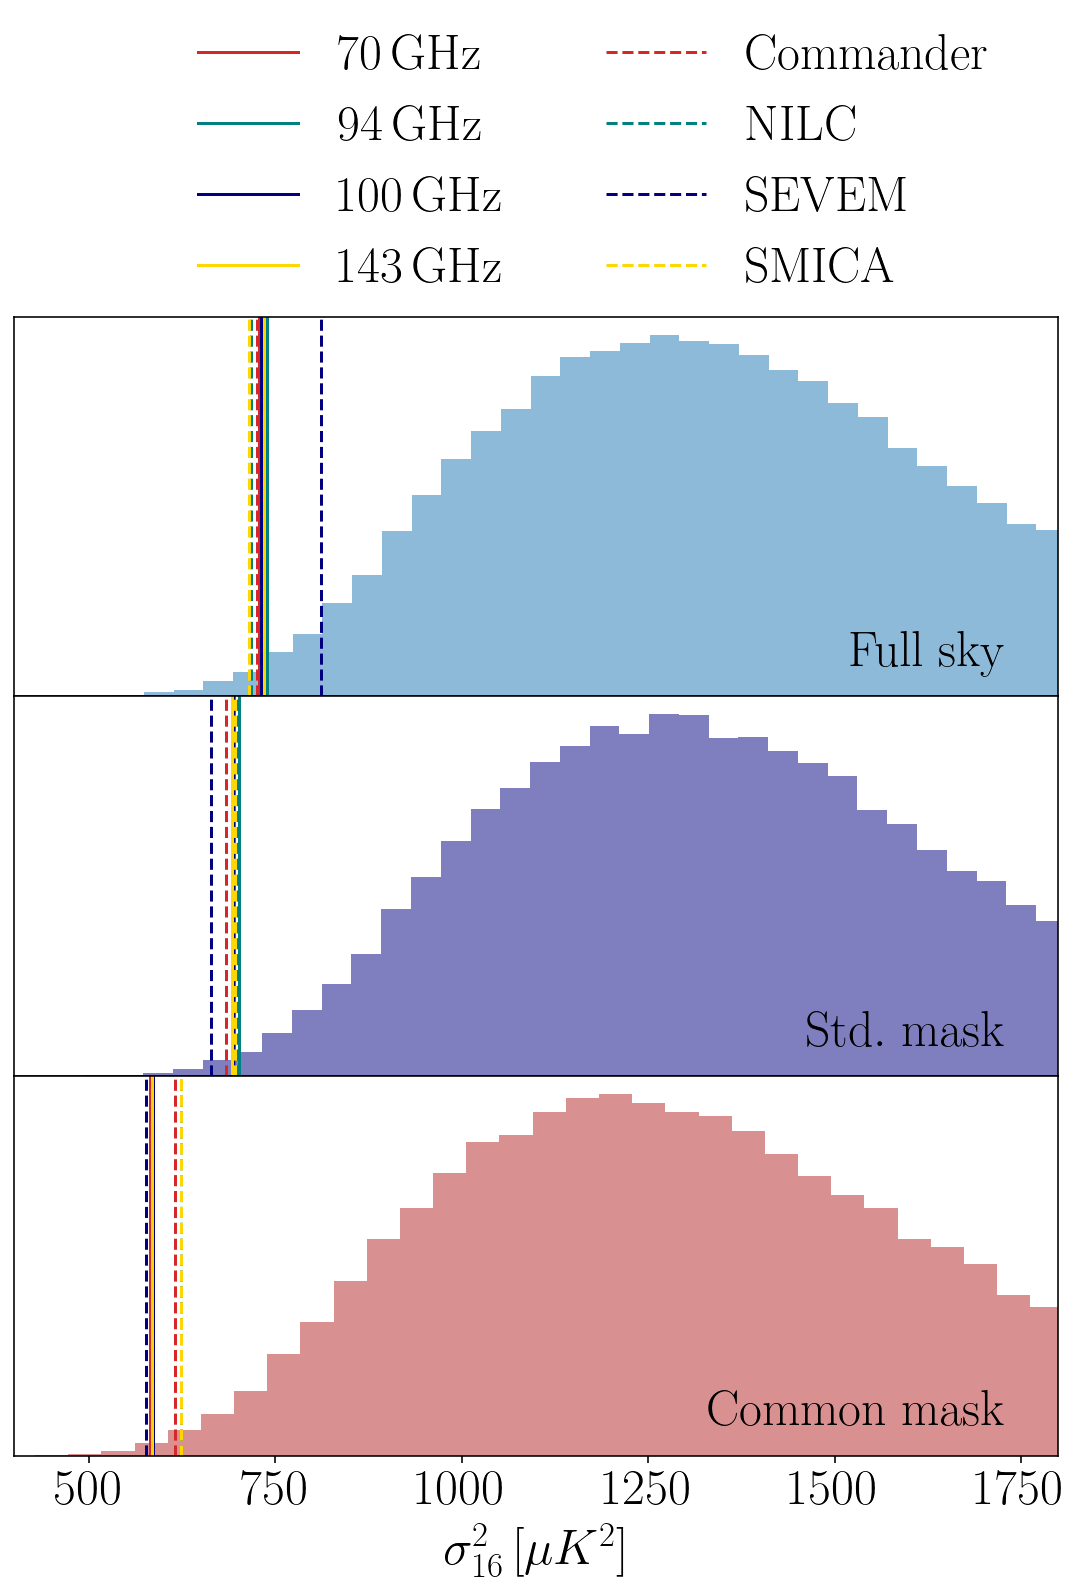

In [16]:
plt.rc('font',**{'family':'Helvetica','size':25})
fig, axs = plt.subplots(Nmasks, 1, figsize=(8, 10), sharex=True, gridspec_kw={'hspace': 0})

for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[m].axvline(vars_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[m].hist(vars_sims[m], bins=100, alpha=0.5, color=colors_mask[m])
    
    axs[m].set_xlim(400, 1800)
    axs[m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[m].text(0.95, 0.05, labels_mask[m], horizontalalignment='right', verticalalignment='bottom', transform=axs[m].transAxes)

axs[-1].set_xlabel(r"$\sigma^2_{16}\, [\mu K^2]$")
fig.legend(labels_Planck, loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.17), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

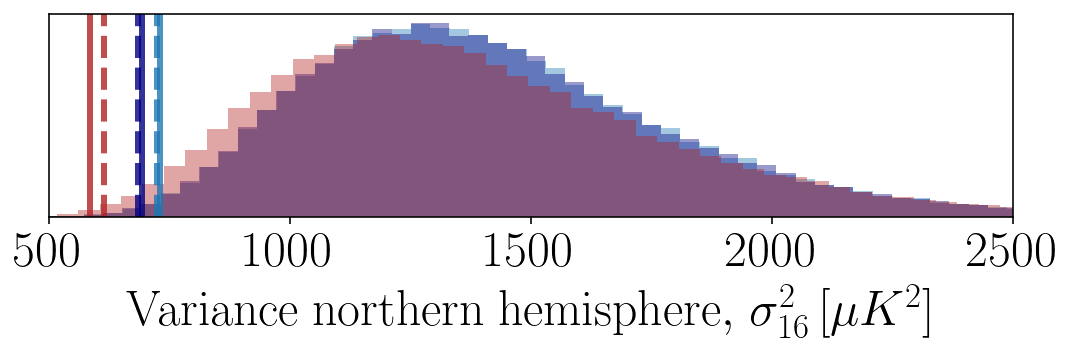

In [17]:
fig = plt.figure(figsize=(8, 3))
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(vars_sims[m], bins=100, alpha=0.4, density=True, color=colors_mask[m])
    plt.axvline(vars_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    plt.axvline(vars_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
plt.xlim(500, 2500)
plt.xlabel(r"$\mathrm{Variance\ northern\ hemisphere,}\ \sigma^2_{16}\, [\mu K^2]$")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
#plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_sigma16.pdf", format="PDF")
plt.show()

## Compute p-values

In [18]:
pvals = [[CMBanom.pval_lower(vars_Planck[m][n], vars_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)]

In [19]:
for m in range(Nmasks):
    print("-----------")
    print(names_mask[m])
    for n in range(Nmaps):
        print(f"sigma_16 = {vars_Planck[m][n]:.2f}, p-value: {100*pvals[m][n]:.2f}% ({names_Planck[n]})")
    #print(f"sigma_16 = {vars_Planck_std_mask[n]:.2f}, p-value: {100*pvals_std_mask[n]:.2f}% ({labels_Planck[n]})")

-----------
fullsky
sigma_16 = 728.11, p-value: 0.59% (cleaned_70GHz_v9_nside_128)
sigma_16 = 738.08, p-value: 0.68% (cleaned_94GHz_v9_nside_128)
sigma_16 = 730.40, p-value: 0.60% (cleaned_100GHz_v9_nside_128)
sigma_16 = 734.52, p-value: 0.65% (cleaned_143GHz_v9_nside_128)
sigma_16 = 725.43, p-value: 0.57% (commander_nside_128)
sigma_16 = 717.79, p-value: 0.51% (nilc_nside_128)
sigma_16 = 811.54, p-value: 1.94% (sevem_nside_128)
sigma_16 = 714.90, p-value: 0.48% (smica_nside_128)
-----------
stdmask
sigma_16 = 694.06, p-value: 0.35% (cleaned_70GHz_v9_nside_128)
sigma_16 = 701.83, p-value: 0.40% (cleaned_94GHz_v9_nside_128)
sigma_16 = 693.62, p-value: 0.35% (cleaned_100GHz_v9_nside_128)
sigma_16 = 692.20, p-value: 0.34% (cleaned_143GHz_v9_nside_128)
sigma_16 = 684.32, p-value: 0.29% (commander_nside_128)
sigma_16 = 699.87, p-value: 0.40% (nilc_nside_128)
sigma_16 = 664.08, p-value: 0.19% (sevem_nside_128)
sigma_16 = 695.82, p-value: 0.37% (smica_nside_128)
-----------
commask
sigma_16 =

### Compare to Jones++ 2023 (common mask)
$\sigma_{16} = 617.6,\ \text{p-value:}\ 0.31\%$ (Commander)

$\sigma_{16} = 605.9,\ \text{p-value:}\ 0.25\%$ (NILC)

$\sigma_{16} = 583.4,\ \text{p-value:}\ 0.16\%$ (SEVEM)

$\sigma_{16} = 631.0,\ \text{p-value:}\ 0.39\%$ (SMICA)

In [20]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*pvals[m][n]:.2f} ", end="")
    print("\\\\")

p-values
fullsky : &0.59 &0.68 &0.60 &0.65 &0.57 &0.51 &1.94 &0.48 \\
stdmask : &0.35 &0.40 &0.35 &0.34 &0.29 &0.40 &0.19 &0.37 \\
commask : &0.14 &0.16 &0.17 &0.15 &0.32 &0.36 &0.13 &0.36 \\


In [21]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{vars_Planck[m][n]:.0f} ", end="")
    print("\\\\")

stats
fullsky : &728 &738 &730 &735 &725 &718 &812 &715 \\
stdmask : &694 &702 &694 &692 &684 &700 &664 &696 \\
commask : &581 &585 &587 &584 &615 &623 &576 &623 \\
